In [1]:
#activate venv: 
import pandas as pd
import time
#other requirements: sklearn, matplotlib, statsmodels

In [2]:
start=time.perf_counter()

In [3]:
from DatabaseCreator import DatabaseCreator
import CJDH_local_settings
from FPLRunningAveragesCalculator import FPLRunningAveragesCalculator

current_season = 20252026
current_gw = 32 #predictions from gw+1

start=time.perf_counter()

if __name__ == "__main__":
    #Run Database Creator
    db_creator = DatabaseCreator(db_settings=CJDH_local_settings.local_settings['FPL_Points_Predictor'])
    fpl_engine = db_creator.get_engine_for("fpl_data_analysis")

    # Initialize the calculator
    calculator = FPLRunningAveragesCalculator(db_creator)
    
    # Define metrics to average
    metrics = ['minutes', 'total_points', 'team_elo', 'opp_team_elo',
        'goals_scored', 'bonus', 'bps', 'clean_sheets', 'goals_conceded',
        'expected_goals', 'expected_assists', 'expected_goal_involvements',
        'expected_goals_conceded', 'cbi', 'defensive_contribution',
        'recoveries', 'tackles', 'saves'
    ]
    
    # Define interaction pairs
    interaction_pairs = [
        ('expected_goal_involvements', 'defensive_contribution'),
    ]
    
    # Calculate running averages
    df = calculator.calculate(
        metrics_to_average=metrics,
        window_sizes=[3, 5, 10],
        include_alltime=True,
        include_per_90=True,
        include_raw=True,
        include_elo_adjusted=True,
        include_squared_per_90=True,
        interaction_pairs=interaction_pairs
    )

    # Identify columns to exclude from forward filling (all fpl playergwdf columns) real life data columns
    exclude_cols = ['player_name_id', 'season', 'event',
                    'fixture', 'total_points', 'minutes',
                    'goals_scored', 'assists', 'team_elo', 'opp_team_elo',
                    'position', 'bonus', 'bps', 'clean_sheets',
                    'goals_conceded', 'was_home', 'expected_assists',
                    'expected_goal_involvements', 'expected_goals', 'expected_goals_conceded',
                    'starts', 'team_name', 'opp_team_name',
                    'cbi','defensive_contribution','recoveries','tackles',
                    'saves']

    # Create a mask for rows to fill: season 20252026 and event > 10
    mask = (df['season'] == current_season) & (df['event'] > current_gw)

    # Get columns to fill
    cols_to_fill = [col for col in df.columns if col not in exclude_cols]

    # Sort by player and event to ensure proper order
    df = df.sort_values(['season', 'player_name_id', 'event'])

    # Forward fill only for the masked rows
    df_filled = df.copy()

    for col in cols_to_fill:
        # Forward fill within each player group
        df_filled.loc[mask, col] = df_filled.groupby('player_name_id')[col].ffill()[mask]

    table_name = "playergw_transformed"
    db_creator.create_staging_table_then_insert_data(table_name, data=df_filled)
    playergw_transformed = db_creator.table_to_df(table_name=table_name)
    
    finish=time.perf_counter()
    print("playergw_transformed inserted into psql")
    print(f'Finished in {round(((finish-start)/60),2)} minute(s)')
    print(playergw_transformed.info())

playergw_transformed inserted into psql
Finished in 28.51 minute(s)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155373 entries, 0 to 155372
Columns: 432 entries, player_name_id to saves_elo_p90sq_10
dtypes: float64(427), object(5)
memory usage: 512.1+ MB
None


In [4]:
from DatabaseCreator import DatabaseCreator
import CJDH_local_settings
from FPLPredictor import FPLPredictor

cbi_defcon_cols = [
    'cbi_at',
    'cbi_p90_at',
    'cbi_3',
    'cbi_p90_3',
    'cbi_elo_3',
    'cbi_elo_p90_3',
    'cbi_5',
    'cbi_p90_5',
    'cbi_elo_5',
    'cbi_elo_p90_5',
    'cbi_10',
    'cbi_p90_10',
    'cbi_elo_10',
    'cbi_elo_p90_10',
    'defensive_cont_at',
    'defensive_cont_p90_at',
    'defensive_cont_3',
    'defensive_cont_p90_3',
    'defensive_cont_elo_3',
    'defensive_cont_elo_p90_3',
    'defensive_cont_5',
    'defensive_cont_p90_5',
    'defensive_cont_elo_5',
    'defensive_cont_elo_p90_5',
    'defensive_cont_10',
    'defensive_cont_p90_10',
    'defensive_cont_elo_10',
    'defensive_cont_elo_p90_10',
    'saves_at',
    'saves_p90_at',
    'saves_3',
    'saves_p90_3',
    'saves_elo_3',
    'saves_elo_p90_3',
    'saves_5',
    'saves_p90_5',
    'saves_elo_5',
    'saves_elo_p90_5',
    'saves_10',
    'saves_p90_10',
    'saves_elo_10',
    'saves_elo_p90_10',
    'recoveries_at',
    'recoveries_p90_at',
    'recoveries_3',
    'recoveries_p90_3',
    'recoveries_elo_3',
    'recoveries_elo_p90_3',
    'recoveries_5',
    'recoveries_p90_5',
    'recoveries_elo_5',
    'recoveries_elo_p90_5',
    'recoveries_10',
    'recoveries_p90_10',
    'recoveries_elo_10',
    'recoveries_elo_p90_10',
    'tackles_at',
    'tackles_p90_at',
    'tackles_3',
    'tackles_p90_3',
    'tackles_elo_3',
    'tackles_elo_p90_3',
    'tackles_5',
    'tackles_p90_5',
    'tackles_elo_5',
    'tackles_elo_p90_5',
    'tackles_10',
    'tackles_p90_10',
    'tackles_elo_10',
    'tackles_elo_p90_10'
]

#Run Database Creator
if __name__ == "__main__":
    db_creator = DatabaseCreator(db_settings=CJDH_local_settings.local_settings['FPL_Points_Predictor'])
    fpl_engine = db_creator.get_engine_for("fpl_data_analysis")

    # Load df from sql
    df = db_creator.run_sql("""SELECT *
                            FROM playergw_transformed
                            """)
    print("=" * 80)
    print("Checking NaN Summary")
    print("=" * 80)

    temp_filtered = (df['minutes']>45)&(df['player_season_minutes_total']>0)
    temp_predictor = FPLPredictor(
        data=df[temp_filtered],
        target='expected_goals_per90',
        positions={'FWD', 'MID','DEF'},
        columns_to_drop=cbi_defcon_cols
    )
    nan_summary = temp_predictor.get_nan_summary()

Checking NaN Summary

NaN Summary for 289 potential features:
Total rows: 43079

Features with NaN values:
                                       feature  nan_count  nan_pct  non_null_count
                        recoveries_elo_p90sq_3      37352    86.71            5727
                            recoveries_p90sq_3      37352    86.71            5727
                           tackles_elo_p90sq_3      37352    86.71            5727
                               tackles_p90sq_3      37352    86.71            5727
                                   cbi_p90sq_3      37352    86.71            5727
                               cbi_elo_p90sq_3      37352    86.71            5727
                        defensive_cont_p90sq_3      37352    86.71            5727
                    defensive_cont_elo_p90sq_3      37352    86.71            5727
                               tackles_p90sq_5      37301    86.59            5778
                           tackles_elo_p90sq_5      37301    86

In [5]:
df[(df['season']==current_season)
   # &(df['team_name']=='Arsenal')
   &(df['event']>20)
   &(df['player_name_id']=='Erling Haaland')
   ][['player_name_id','event','opp_team_name','total_points','minutes','expected_goals','xgoals_p90sq_at']].sort_values(by='event')

,player_name_id,event,opp_team_name,total_points,minutes,expected_goals,xgoals_p90sq_at
140785,Erling Haaland,21.0,Brighton,6.0,90.0,1.53,1.118346
140787,Erling Haaland,22.0,Man Utd,2.0,79.0,0.13,1.128707
140789,Erling Haaland,23.0,Wolves,1.0,17.0,0.00,1.119406
140793,Erling Haaland,24.0,Spurs,5.0,90.0,0.28,1.110078
140795,Erling Haaland,25.0,Liverpool,11.0,90.0,1.35,1.101552
140797,Erling Haaland,26.0,Fulham,5.0,45.0,0.12,1.107461
140799,Erling Haaland,27.0,Newcastle,6.0,90.0,0.31,1.098926
140801,Erling Haaland,28.0,Leeds,0.0,0.0,0.00,1.090838
140803,Erling Haaland,29.0,Nott'm Forest,2.0,90.0,0.10,1.090838
140805,Erling Haaland,30.0,West Ham,2.0,90.0,0.30,1.082192


In [6]:
# #restricts to player_name_id who have >0 minutes in that season
# #model struggles to predict higher values, so maybe cut-off points at 10, or try log(points) as a depvar
# for each indepvar: filter outliers & standardize

In [7]:
# #Optimizing hyperparameters

# filtered = (df['minutes']>45)&(df['player_season_minutes_total']>100)#&(df['expected_goals']>0)

# if __name__ == "__main__":

#     print("\n" + "=" * 80)
#     print("FWD xG Predictor with GridSearch Optimization and NaN Filtering")
#     print("=" * 80)
    
#     FWD_xG_predictor = FPLPredictor(
#         data=df[filtered],
#         target='expected_goals_per90',
#         positions={'FWD'},
#         columns_to_drop=cbi_defcon_cols,
#         optimize=True,  # Enable GridSearchCV
#         param_grid={
#             'n_estimators': [200],
#             'max_depth': [20, 30, 50],
#             'min_samples_split': [50, 100, 200, 300]
#         },
#         cv_folds=5,
#         max_nan_pct=10  # Remove features with >10% NaN values
#     )
#     FWD_xG_predictor.fit()
#     FWD_xG_predictor.plot_cv_results()
    
#     # Get best parameters in grid format
#     FWD_params_grid = FWD_xG_predictor.get_best_params_as_grid()
#     #Get largest errors
#     FWD_xG_errors = FWD_xG_predictor.get_largest_errors(return_full_data=True)

#     print("\n" + "=" * 80)
#     print("MID xG Predictor with GridSearch Optimization and NaN Filtering")
#     print("=" * 80)

#     MID_xG_predictor = FPLPredictor(
#         data=df[filtered],
#         target='expected_goals_per90',
#         positions={'MID'},
#         columns_to_drop=cbi_defcon_cols,
#         optimize=True,  # Enable GridSearchCV
#         param_grid={
#             'n_estimators': [200],
#             'max_depth': [20, 30, 50],
#             'min_samples_split': [50, 100, 200, 300] # cannot be larger than sample size!
#         },
#         cv_folds=5,
#         max_nan_pct=10  # Remove features with >10% NaN values
#     )
#     MID_xG_predictor.fit()
#     MID_xG_predictor.plot_cv_results()

#     # Get best parameters in grid format
#     MID_params_grid = MID_xG_predictor.get_best_params_as_grid()
#     #Get largest errors
#     MID_xG_errors = MID_xG_predictor.get_largest_errors(return_full_data=True)

#     print("\n" + "=" * 80)
#     print("DEF xG Predictor with GridSearch Optimization and NaN Filtering")
#     print("=" * 80)

#     DEF_xG_predictor = FPLPredictor(
#         data=df[filtered],
#         target='expected_goals_per90',
#         positions={'DEF'},
#         columns_to_drop=cbi_defcon_cols,
#         optimize=True,  # Enable GridSearchCV
#         param_grid={
#             'n_estimators': [200],
#             'max_depth': [20, 30, 50],
#             'min_samples_split': [50, 100, 200, 300]
#         },
#         cv_folds=5,
#         max_nan_pct=10  # Remove features with >10% NaN values
#     )
#     DEF_xG_predictor.fit()
#     DEF_xG_predictor.plot_cv_results()

#     # Get best parameters in grid format
#     DEF_params_grid = DEF_xG_predictor.get_best_params_as_grid()
#     #Get largest errors
#     DEF_xG_errors = DEF_xG_predictor.get_largest_errors(return_full_data=True)


In [8]:
# print(FWD_params_grid)
# print(MID_params_grid)
# print(DEF_params_grid)

In [9]:
# FWD_params_grid = {'max_depth': [30], 'min_samples_split': [200], 'n_estimators': [200]}
# MID_params_grid = {'max_depth': [30], 'min_samples_split': [200], 'n_estimators': [200]}
# DEF_params_grid = {'max_depth': [30], 'min_samples_split': [200], 'n_estimators': [200]}

#quick version
FWD_params_grid = {'max_depth': [5], 'min_samples_split': [200], 'n_estimators': [10]}
MID_params_grid = {'max_depth': [5], 'min_samples_split': [200], 'n_estimators': [10]}
DEF_params_grid = {'max_depth': [5], 'min_samples_split': [200], 'n_estimators': [10]}

In [10]:
# target=expected_goals_per90, FWD_xG_predictor
# Cleaned df size: 2450/4170

# Performing GridSearchCV hyperparameter optimization...
# Parameter grid: {'n_estimators': [200], 'max_depth': [20, 30, 50], 'min_samples_split': [500]}
# Cross-validation folds: 5
# Fitting 5 folds for each of 3 candidates, totalling 15 fits

# Best parameters found:
#   max_depth: 20
#   min_samples_split: 500
#   n_estimators: 200

# Best CV RMSE: 0.4231

# Training Set Performance:
# R² Score: 0.1823
# RMSE: 0.4056
# MAE: 0.2978

# Test Set Performance:
# R² Score: 0.1273
# RMSE: 0.4301
# MAE: 0.3197

In [11]:
mins_filter = (df['player_season_minutes_total']>100)&(df['minutes']>0)

if __name__ == "__main__":
    
    FWD_mins_predictor = FPLPredictor(
                data=df[mins_filter],
        target='minutes',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=50
        )
    FWD_mins_predictor.fit()
    # FWD_mins_predictor.plot_results()

    MID_mins_predictor = FPLPredictor(
        data=df[mins_filter],
        target='minutes',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=50
        )
    MID_mins_predictor.fit()
    # MID_mins_predictor.plot_results()

    DEF_mins_predictor = FPLPredictor(
        data=df[mins_filter],
        target='minutes',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=50
        )
    DEF_mins_predictor.fit()
    # DEF_mins_predictor.plot_results()

    GK_mins_predictor = FPLPredictor(
        data=df[mins_filter],
        target='minutes',
        positions={'GK'},
        columns_to_drop = cbi_defcon_cols,
        max_nan_pct=10
        )
    GK_mins_predictor.fit()
    # GK_mins_predictor.plot_results()

Cleaned df size: 2657/7993

Training Set Performance:
R² Score: 0.8241
RMSE: 13.6809
MAE: 11.3133

Test Set Performance:
R² Score: 0.4009
RMSE: 25.7153
MAE: 21.3087

Top 20 Feature Importances:
                 feature  importance
               minutes_3    0.307379
           minutes_elo_3    0.039867
    opp_team_elo_p90sq_3    0.027650
    opp_team_elo_p90sq_5    0.014621
       team_elo_p90sq_at    0.010277
   opp_team_elo_p90sq_at    0.009493
        team_elo_p90sq_5    0.009261
   clean_sheets_p90sq_at    0.008972
                 fixture    0.008873
 goals_conceded_p90sq_at    0.008464
            opp_team_elo    0.008146
         opp_team_elo_10    0.008082
          opp_team_elo_5    0.008060
                elo_diff    0.008051
 opp_team_elo_elo_p90_10    0.007609
          opp_team_elo_3    0.007092
         xg_over_g_ratio    0.007064
            bps_p90sq_at    0.006529
   opp_team_elo_p90sq_10    0.006416
opp_team_elo_elo_p90sq_5    0.006220
Cleaned df size: 9171/29770



In [12]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>0)&(df['total_points']<12)

if __name__ == "__main__":
    
    print("target=expected_goals_per90, FWD_xG_predictor")
    FWD_xG_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_per90',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_xG_predictor.fit()
    # FWD_xG_predictor.plot_results()

    print("target=expected_goals_per90, MID_xG_predictor")
    MID_xG_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_xG_predictor.fit()
    # MID_xG_predictor.plot_results()
    
    print("target=expected_goals_per90, DEF_xG_predictor")
    DEF_xG_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_xG_predictor.fit()
    # DEF_xG_predictor.plot_results()

target=expected_goals_per90, FWD_xG_predictor
Cleaned df size: 2765/4598

Training Set Performance:
R² Score: 0.5997
RMSE: 0.2491
MAE: 0.1989

Test Set Performance:
R² Score: 0.0420
RMSE: 0.3596
MAE: 0.2802

Top 20 Feature Importances:
                  feature  importance
                 elo_diff    0.059032
                  fixture    0.036931
    goals_scored_p90sq_at    0.036548
          xg_over_g_ratio    0.032051
          opp_team_elo_10    0.018485
             opp_team_elo    0.018091
           bonus_p90sq_at    0.017470
           opp_team_elo_5    0.014635
     opp_team_elo_p90sq_3    0.013720
            minutes_elo_3    0.013604
         team_elo_p90sq_3    0.013594
           opp_team_elo_3    0.011954
         team_elo_p90sq_5    0.011551
                 team_elo    0.010561
total_points_elo_p90sq_10    0.010485
        minutes_elo_p90_3    0.010443
     opp_team_elo_p90sq_5    0.010183
    clean_sheets_p90sq_at    0.009687
    opp_team_elo_p90sq_10    0.009395
    

In [13]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>100)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=expected_assists_per90, FWD_xA_predictor")
    FWD_xA_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_assists_per90',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_xA_predictor.fit()
    # FWD_xA_predictor.plot_results()

    print("target=expected_assists_per90, MID_xA_predictor")
    MID_xA_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_assists_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_xA_predictor.fit()
    # MID_xA_predictor.plot_results()
    
    print("target=expected_assists_per90, DEF_xA_predictor")
    DEF_xA_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_assists_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_xA_predictor.fit()
    # DEF_xA_predictor.plot_results()

target=expected_assists_per90, FWD_xA_predictor
Cleaned df size: 2969/4899

Training Set Performance:
R² Score: 0.5339
RMSE: 0.0808
MAE: 0.0551

Test Set Performance:
R² Score: 0.0006
RMSE: 0.1263
MAE: 0.0738

Top 20 Feature Importances:
                 feature  importance
                 fixture    0.045962
            opp_team_elo    0.043256
    goals_conceded_elo_3    0.030175
    total_points_p90sq_3    0.025557
       minutes_elo_p90_5    0.021324
                elo_diff    0.020495
            bonus_elo_10    0.017446
 opp_team_elo_elo_p90_10    0.015311
         xg_over_g_ratio    0.013319
       minutes_elo_p90_3    0.012905
         opp_team_elo_10    0.012286
             bps_p90sq_3    0.012231
   goals_scored_p90sq_at    0.011836
 goals_conceded_p90sq_at    0.011518
          opp_team_elo_3    0.011432
       team_elo_p90sq_at    0.011314
  opp_team_elo_elo_p90_5    0.010670
total_points_elo_p90sq_3    0.009904
    opp_team_elo_p90sq_3    0.009788
    goals_conceded_elo

In [14]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>100)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=expected_goals_conceded_per90, FWD_xGC_predictor")
    FWD_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_xGC_predictor.fit()
    # FWD_xGC_predictor.plot_results()

    print("target=expected_goals_conceded_per90, MID_xGC_predictor")
    MID_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_xGC_predictor.fit()
    # MID_xGC_predictor.plot_results()
    
    print("target=expected_goals_conceded_per90, DEF_xGC_predictor")
    DEF_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_xGC_predictor.fit()
    # DEF_xGC_predictor.plot_results()

    print("target=expected_goals_conceded_per90, GK_xGC_predictor")
    GK_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'GK'},
        columns_to_drop = cbi_defcon_cols,
        max_nan_pct=10)
    GK_xGC_predictor.fit()
    # GK_xGC_predictor.plot_results()

target=expected_goals_conceded_per90, FWD_xGC_predictor
Cleaned df size: 2969/4899

Training Set Performance:
R² Score: 0.6843
RMSE: 0.5280
MAE: 0.4289

Test Set Performance:
R² Score: 0.2477
RMSE: 0.7375
MAE: 0.5842

Top 20 Feature Importances:
                feature  importance
               elo_diff    0.166437
                fixture    0.056389
           opp_team_elo    0.037224
        xg_over_g_ratio    0.036732
        opp_team_elo_10    0.017976
         opp_team_elo_5    0.017741
    minutes_elo_p90sq_3    0.014229
  clean_sheets_p90sq_at    0.014182
goals_conceded_p90sq_at    0.013349
         opp_team_elo_3    0.012122
     minutes_elo_p90_10    0.011700
         bonus_p90sq_at    0.009624
      team_elo_p90sq_at    0.009062
goals_conceded_p90sq_10    0.008968
  goals_scored_p90sq_at    0.008637
               team_elo    0.007794
  total_points_p90sq_at    0.007791
  goals_conceded_elo_10    0.007685
 goals_conceded_p90sq_3    0.007537
             minutes_10    0.00742

In [15]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>100)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=bps_per90, FWD_bps_predictor")
    FWD_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90', # try: 'bonus_per90'
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_bps_predictor.fit()
    # FWD_bps_predictor.plot_results()

    print("target=bps_per90, MID_bps_predictor")
    MID_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_bps_predictor.fit()
    # MID_bps_predictor.plot_results()
    
    print("target=bps_per90, DEF_bps_predictor")
    DEF_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_bps_predictor.fit()
    # DEF_bps_predictor.plot_results()

    print("target=bps_per90, GK_bps_predictor")
    GK_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90',
        positions={'GK'},
        columns_to_drop = cbi_defcon_cols,
        max_nan_pct=10)
    GK_bps_predictor.fit()
    # GK_bps_predictor.plot_results()

target=bps_per90, FWD_bps_predictor
Cleaned df size: 4381/4899

Training Set Performance:
R² Score: 0.4645
RMSE: 13.5155
MAE: 10.9993

Test Set Performance:
R² Score: 0.0242
RMSE: 18.1904
MAE: 14.0769

Top 20 Feature Importances:
                  feature  importance
                 elo_diff    0.077960
             opp_team_elo    0.027165
          opp_team_elo_10    0.021563
           opp_team_elo_3    0.019733
                  fixture    0.018366
  goals_conceded_p90sq_at    0.016719
        minutes_elo_p90_5    0.014004
           opp_team_elo_5    0.012829
    total_points_p90sq_at    0.012388
                bps_elo_3    0.012351
clean_sheets_elo_p90sq_10    0.011767
           bonus_p90sq_at    0.011724
     goals_conceded_elo_3    0.010960
               bps_elo_10    0.010388
    opp_team_elo_p90sq_at    0.009940
     minutes_elo_p90sq_10    0.009542
                   bps_10    0.009331
      minutes_elo_p90sq_5    0.009005
        minutes_elo_p90_3    0.008642
    clean_

In [16]:
#shots saved
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>0)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=saves_per90, GK_saves_predictor")
    GK_saves_predictor = FPLPredictor(
        data=df[filtered],
        target='saves_per90',
        positions={'GK'},
        max_nan_pct=10)
    GK_saves_predictor.fit()
    # GK_saves_predictor.plot_results()

target=saves_per90, GK_saves_predictor
Cleaned df size: 4112/4382

Training Set Performance:
R² Score: 0.5583
RMSE: 1.2965
MAE: 1.0524

Test Set Performance:
R² Score: 0.0530
RMSE: 1.8992
MAE: 1.4797

Top 20 Feature Importances:
                    feature  importance
                   elo_diff    0.141119
               opp_team_elo    0.019640
             saves_p90sq_at    0.016989
                    fixture    0.015937
             opp_team_elo_5    0.015090
      opp_team_elo_p90sq_at    0.015082
             saves_p90sq_10    0.014224
            opp_team_elo_10    0.013954
    goals_conceded_p90sq_at    0.013845
          team_elo_p90sq_at    0.013791
         saves_elo_p90sq_10    0.013511
          saves_elo_p90sq_5    0.013224
               bps_p90sq_at    0.012697
      clean_sheets_p90sq_at    0.012184
   total_points_elo_p90sq_3    0.011716
             opp_team_elo_3    0.011314
goals_conceded_elo_p90sq_10    0.011284
       opp_team_elo_p90sq_5    0.010760
          s

In [17]:
# >10 defcon (CBIT) for a defender
# >12 defcon (CBIT+R) for mid or fwd
filtered = (df['minutes']>30)&(df['player_season_minutes_total']>0)

if __name__ == "__main__":
    
    print("target=defensive_contribution_per90, FWD_defcon_predictor")
    FWD_defcon_predictor = FPLPredictor(
        data=df[filtered],
        target='defensive_contribution_per90',
        positions={'FWD'},
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_defcon_predictor.fit()
    # FWD_defcon_predictor.plot_results()

    print("target=defensive_contribution_per90, MID_defcon_predictor")
    MID_defcon_predictor = FPLPredictor(
        data=df[filtered],
        target='defensive_contribution_per90',
        positions={'MID'},
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_defcon_predictor.fit()
    # MID_defcon_predictor.plot_results()

    print("target=defensive_contribution_per90, DEF_defcon_predictor")
    DEF_defcon_predictor = FPLPredictor(
        data=df[filtered],
        target='defensive_contribution_per90',
        positions={'DEF'},
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_defcon_predictor.fit()
    # DEF_defcon_predictor.plot_results()

target=defensive_contribution_per90, FWD_defcon_predictor
Cleaned df size: 686/5410

Training Set Performance:
R² Score: 0.7820
RMSE: 1.3710
MAE: 1.1121

Test Set Performance:
R² Score: -0.2042
RMSE: 2.8963
MAE: 2.2796

Top 20 Feature Importances:
                feature  importance
             minutes_10    0.075820
         opp_team_elo_5    0.022783
  clean_sheets_p90sq_at    0.022180
           bps_p90sq_at    0.020595
   goals_conceded_p90_5    0.020541
         opp_team_elo_3    0.018560
            bps_p90sq_5    0.018374
goals_conceded_p90sq_at    0.017215
           opp_team_elo    0.016596
                fixture    0.015445
        xg_over_g_ratio    0.015222
               team_elo    0.014840
  goals_scored_p90sq_at    0.014360
   total_points_p90sq_3    0.014268
  opp_team_elo_p90sq_at    0.011693
        opp_team_elo_10    0.011569
         bonus_p90sq_at    0.011194
     team_elo_elo_p90_5    0.011052
                  bps_3    0.011032
  opp_team_elo_p90sq_10    0.010

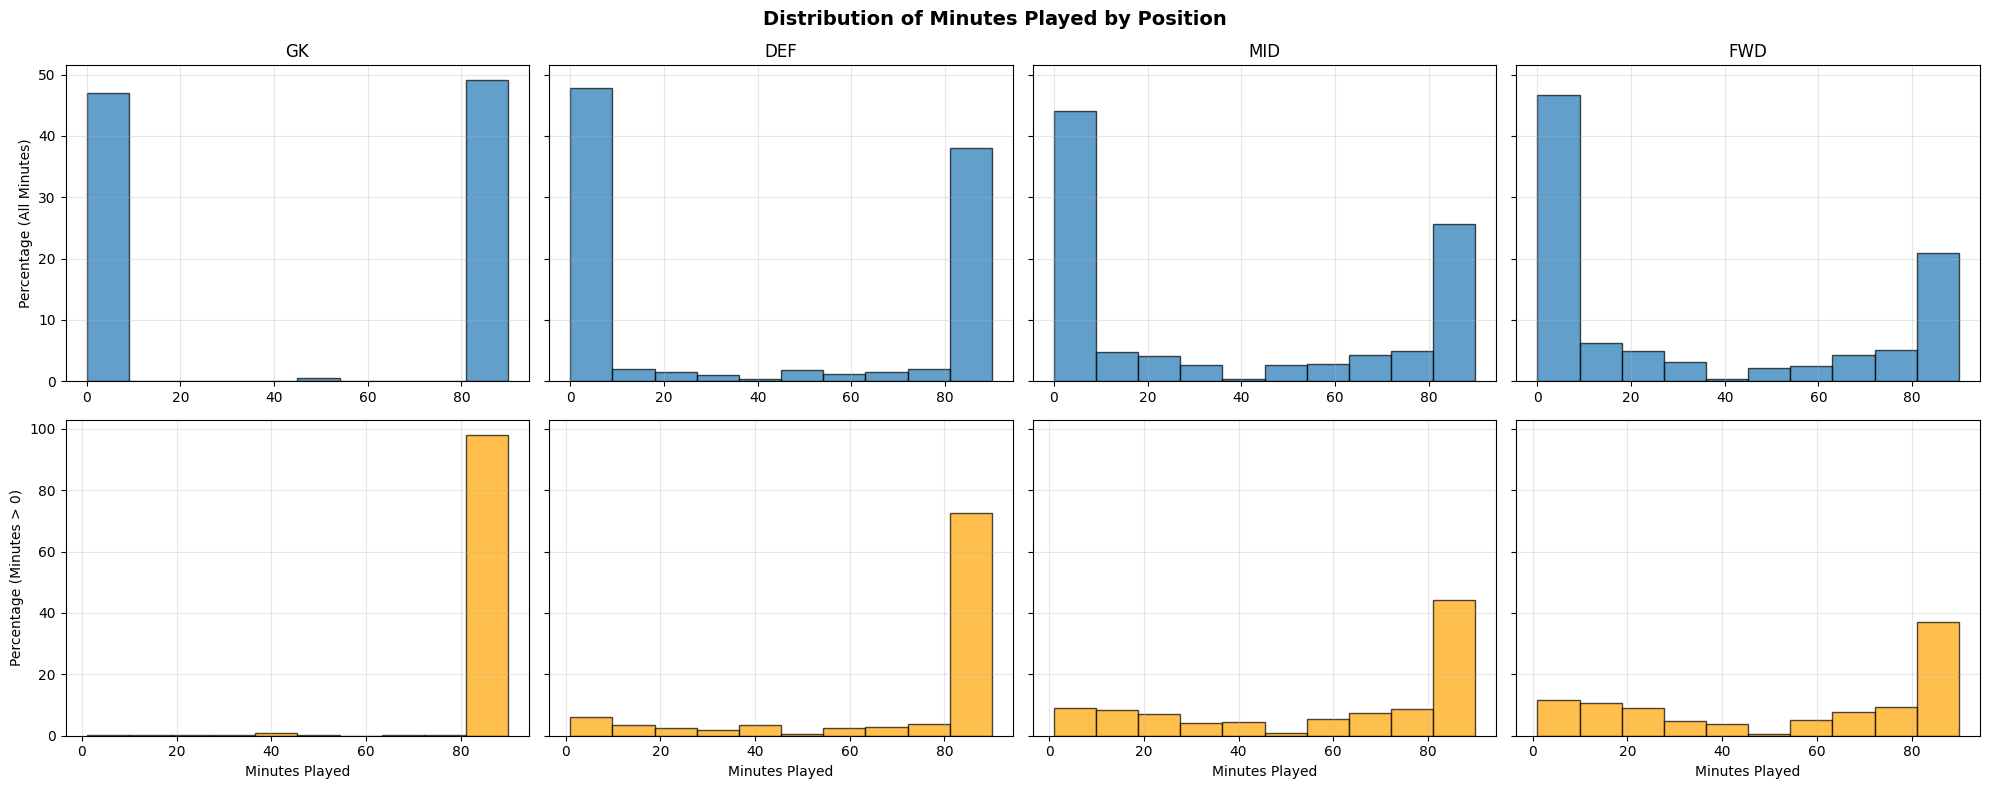

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Filter for specific positions
positions = ['GK', 'DEF', 'MID', 'FWD']
n_positions = len(positions)

# Create subplots with 2 rows
fig, axes = plt.subplots(2, n_positions, figsize=(5*n_positions, 8), sharey='row')

# Row 1: All data
for i, position in enumerate(positions):
    position_minutes = df[df['position'] == position]['minutes']
    axes[0, i].hist(position_minutes, bins=10, edgecolor='black', alpha=0.7, 
                    weights=100*np.ones(len(position_minutes))/len(position_minutes))
    axes[0, i].set_title(position)
    axes[0, i].grid(True, alpha=0.3)

axes[0, 0].set_ylabel('Percentage (All Minutes)')

# Row 2: Minutes > 0
for i, position in enumerate(positions):
    position_minutes = df[(df['position'] == position) & (df['minutes'] > 0)]['minutes']
    axes[1, i].hist(position_minutes, bins=10, edgecolor='black', alpha=0.7, color='orange',
                    weights=100*np.ones(len(position_minutes))/len(position_minutes))
    axes[1, i].set_xlabel('Minutes Played')
    axes[1, i].grid(True, alpha=0.3)

axes[1, 0].set_ylabel('Percentage (Minutes > 0)')

plt.suptitle('Distribution of Minutes Played by Position', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Goals conceded per 90
Estimated λ (mean goals per match): 1.364


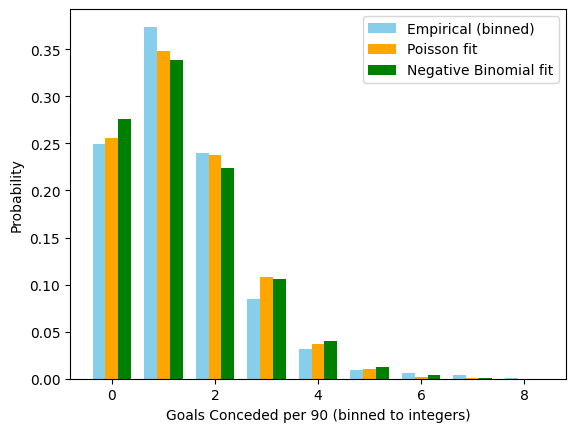

Mean: 1.355, Variance: 1.495
Overdispersion ratio (Var/Mean): 1.103
✅ Poisson assumption looks reasonable.
P(X < 1 goal) = 0.256


In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, nbinom
print("Goals conceded per 90")

# Compute xGC per 90
data = df.copy()
data['xgc_p90'] = (data['expected_goals_conceded'] / data['minutes']) * 90

# Filter to reasonable samples
data = data[(data['minutes'] > 0) & (data['xgc_p90'] < 8)]['xgc_p90']

# Estimate λ
lambda_hat = np.mean(data)
print(f"Estimated λ (mean goals per match): {lambda_hat:.3f}")

# --- BINNING into discrete Poisson-like counts ---
binned = np.round(data).astype(int)
binned = np.clip(binned, 0, None)

# Empirical frequencies
values, counts = np.unique(binned, return_counts=True)
prob_empirical = counts / counts.sum()

# --- Poisson PMF ---
poisson_pmf = poisson.pmf(values, mu=lambda_hat)

# --- Negative Binomial PMF (method of moments) ---
mean_val = np.mean(binned)
var_val = np.var(binned, ddof=1)

if var_val > mean_val:
    r = (mean_val ** 2) / (var_val - mean_val)
    p = r / (r + mean_val)
    negbin_pmf = nbinom.pmf(values, n=r, p=p)
else:
    negbin_pmf = np.zeros_like(values)
    print("Variance ≤ Mean → NB undefined, skipping NB plot.")

# --- Plot ---
plt.bar(values - 0.25, prob_empirical, width=0.25, label='Empirical (binned)', color='skyblue')
plt.bar(values, poisson_pmf, width=0.25, label='Poisson fit', color='orange')
plt.bar(values + 0.25, negbin_pmf, width=0.25, label='Negative Binomial fit', color='green')
plt.xlabel('Goals Conceded per 90 (binned to integers)')
plt.ylabel('Probability')
plt.legend()
plt.show()

# --- Dispersion diagnostics ---
overdispersion_ratio = var_val / mean_val
print(f"Mean: {mean_val:.3f}, Variance: {var_val:.3f}")
print(f"Overdispersion ratio (Var/Mean): {overdispersion_ratio:.3f}")

if overdispersion_ratio > 1.2:
    print("⚠️ Likely overdispersed → Negative Binomial may fit better.")
else:
    print("✅ Poisson assumption looks reasonable.")

# --- Example probability ---
p_less_than_1 = poisson.cdf(0, mu=lambda_hat)
print(f"P(X < 1 goal) = {p_less_than_1:.3f}")


Mids & Forwards
Estimated λ (mean defcon per 90): 8.228


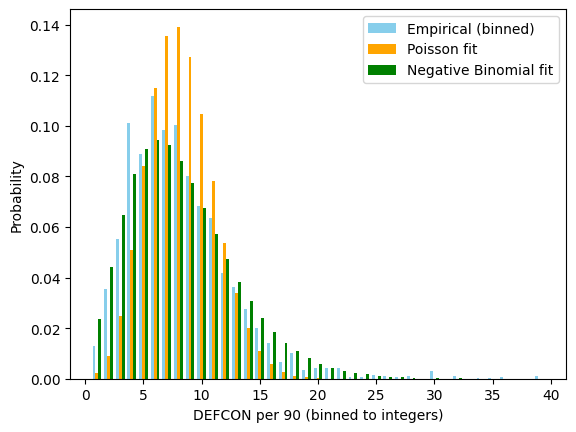

Mean: 8.220, Variance: 21.427
Overdispersion ratio (Var/Mean): 2.607
⚠️ Likely overdispersed → Negative Binomial may fit better.


In [20]:
#Test if defcon_p90 is neg binom distributed

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, nbinom
print("Mids & Forwards")

# Filter to reasonable samples
data = df[(df['minutes'] > 0)
          & (df['defensive_contribution_per90'] > 0) 
          & (df['defensive_contribution_per90'] < 40)
          & (df['position'].isin(['DEF']))]['defensive_contribution_per90']

# Estimate λ
lambda_hat = np.mean(data)
print(f"Estimated λ (mean defcon per 90): {lambda_hat:.3f}")

# --- BINNING into discrete Poisson-like counts ---
binned = np.round(data).astype(int)
binned = np.clip(binned, 0, None)

# Empirical frequencies
values, counts = np.unique(binned, return_counts=True)
prob_empirical = counts / counts.sum()

# --- Poisson PMF ---
poisson_pmf = poisson.pmf(values, mu=lambda_hat)

# --- Negative Binomial PMF (method of moments) ---
mean_val = np.mean(binned)
var_val = np.var(binned, ddof=1)

if var_val > mean_val:
    r = (mean_val ** 2) / (var_val - mean_val)
    p = r / (r + mean_val)
    negbin_pmf = nbinom.pmf(values, n=r, p=p)
else:
    negbin_pmf = np.zeros_like(values)
    print("Variance ≤ Mean → NB undefined, skipping NB plot.")

# --- Plot ---
plt.bar(values - 0.25, prob_empirical, width=0.25, label='Empirical (binned)', color='skyblue')
plt.bar(values, poisson_pmf, width=0.25, label='Poisson fit', color='orange')
plt.bar(values + 0.25, negbin_pmf, width=0.25, label='Negative Binomial fit', color='green')
plt.xlabel('DEFCON per 90 (binned to integers)')
plt.ylabel('Probability')
plt.legend()
plt.show()

# --- Dispersion diagnostics ---
overdispersion_ratio = var_val / mean_val
print(f"Mean: {mean_val:.3f}, Variance: {var_val:.3f}")
print(f"Overdispersion ratio (Var/Mean): {overdispersion_ratio:.3f}")

if overdispersion_ratio > 1.2:
    print("⚠️ Likely overdispersed → Negative Binomial may fit better.")
else:
    print("✅ Poisson assumption looks reasonable.")


GK saves per 90
Estimated λ (mean saves per 90): 3.197


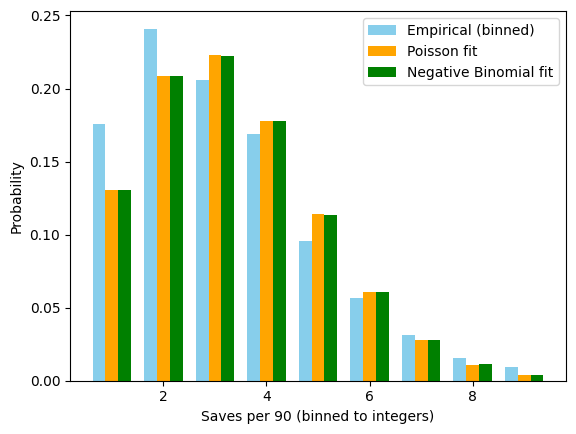

Mean: 3.197, Variance: 3.202
Overdispersion ratio (Var/Mean): 1.001
✅ Poisson assumption looks reasonable.


In [21]:
#Test if saves_p90 is neg binom distributed

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, nbinom
print("GK saves per 90")

# Filter to reasonable samples
data = df[#(df['minutes'] > 0)
          (df['saves_per90'] > 0) 
          & (df['saves_per90'] < 10)
          & (df['position'].isin(['GK']))]['saves_per90']

# Estimate λ
lambda_hat = np.mean(data)
print(f"Estimated λ (mean saves per 90): {lambda_hat:.3f}")

# --- BINNING into discrete Poisson-like counts ---
binned = np.round(data).astype(int)
binned = np.clip(binned, 0, None)

# Empirical frequencies
values, counts = np.unique(binned, return_counts=True)
prob_empirical = counts / counts.sum()

# --- Poisson PMF ---
poisson_pmf = poisson.pmf(values, mu=lambda_hat)

# --- Negative Binomial PMF (method of moments) ---
mean_val = np.mean(binned)
var_val = np.var(binned, ddof=1)

if var_val > mean_val:
    r = (mean_val ** 2) / (var_val - mean_val)
    p = r / (r + mean_val)
    negbin_pmf = nbinom.pmf(values, n=r, p=p)
else:
    negbin_pmf = np.zeros_like(values)
    print("Variance ≤ Mean → NB undefined, skipping NB plot.")

# --- Plot ---
plt.bar(values - 0.25, prob_empirical, width=0.25, label='Empirical (binned)', color='skyblue')
plt.bar(values, poisson_pmf, width=0.25, label='Poisson fit', color='orange')
plt.bar(values + 0.25, negbin_pmf, width=0.25, label='Negative Binomial fit', color='green')
plt.xlabel('Saves per 90 (binned to integers)')
plt.ylabel('Probability')
plt.legend()
plt.show()

# --- Dispersion diagnostics ---
overdispersion_ratio = var_val / mean_val
print(f"Mean: {mean_val:.3f}, Variance: {var_val:.3f}")
print(f"Overdispersion ratio (Var/Mean): {overdispersion_ratio:.3f}")

if overdispersion_ratio > 1.2:
    print("⚠️ Likely overdispersed → Negative Binomial may fit better.")
else:
    print("✅ Poisson assumption looks reasonable.")


In [22]:
#Create the data which the prediction data should be added to
prediction_data = df[(df['season']==20252026)
                     &(df['event']>=current_gw+1)]

In [23]:
def predict_target_vectorized(df, model_dict, col_name):
    preds = []
    
    for pos, model in model_dict.items():
        subset = df[df['position'] == pos]
        if not subset.empty:
            pos_preds = model.predict_new(subset)
            temp = subset.copy()
            temp[col_name] = pos_preds
            preds.append(temp)
    
    if not preds:
        # If no positions matched at all
        return pd.Series(index=df.index, dtype=float)
    
    result = pd.concat(preds)
    
    # Safely align back to original DataFrame
    output = pd.Series(index=df.index, dtype=float)
    output.loc[result.index] = result[col_name]
    return output

In [24]:
target_col_name = 'mins_pred'
mins_model_dict = {'FWD': FWD_mins_predictor, 'MID': MID_mins_predictor, 'DEF': DEF_mins_predictor, 'GK': GK_mins_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, mins_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_18360\2521843321.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, mins_model_dict, col_name=target_col_name)


count    3126.000000
mean       58.120939
std        19.690701
min        14.499023
25%        39.987418
50%        59.246059
75%        75.028319
max        89.952353
Name: mins_pred, dtype: float64

In [25]:
target_col_name = 'xgp90_pred'
xg_model_dict = {'FWD': FWD_xG_predictor, 'MID': MID_xG_predictor, 'DEF': DEF_xG_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xg_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_18360\365369552.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xg_model_dict, col_name=target_col_name)


count    2916.000000
mean        0.184294
std         0.144939
min         0.037217
25%         0.060128
50%         0.149074
75%         0.258826
max         0.789675
Name: xgp90_pred, dtype: float64

In [26]:
target_col_name = 'xap90_pred'
xA_model_dict = {'FWD': FWD_xA_predictor, 'MID': MID_xA_predictor, 'DEF': DEF_xA_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xA_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_18360\4144355699.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xA_model_dict, col_name=target_col_name)


count    2916.000000
mean        0.110807
std         0.071739
min         0.030960
25%         0.053918
50%         0.088914
75%         0.143173
max         0.427410
Name: xap90_pred, dtype: float64

In [27]:
target_col_name = 'xgcp90_pred'
xGC_model_dict = {'FWD': FWD_xGC_predictor, 'MID': MID_xGC_predictor, 'DEF': DEF_xGC_predictor, 'GK':GK_xGC_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xGC_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_18360\682035545.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xGC_model_dict, col_name=target_col_name)


count    3126.000000
mean        1.566357
std         0.384190
min         0.439160
25%         1.335796
50%         1.506992
75%         1.750599
max         2.997835
Name: xgcp90_pred, dtype: float64

In [28]:
target_col_name = 'xbpsp90_pred'
bps_model_dict = {'FWD': FWD_bps_predictor, 'MID': MID_bps_predictor, 'DEF': DEF_bps_predictor, 'GK':GK_bps_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, bps_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_18360\3051138591.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, bps_model_dict, col_name=target_col_name)


count    3126.000000
mean       16.272944
std         3.974188
min         3.926487
25%        13.655753
50%        15.908865
75%        18.225971
max        34.378384
Name: xbpsp90_pred, dtype: float64

                                 OLS Regression Results                                
Dep. Variable:                  bonus   R-squared (uncentered):                   0.447
Model:                            OLS   Adj. R-squared (uncentered):              0.447
Method:                 Least Squares   F-statistic:                          3.676e+04
Date:                Sun, 12 Apr 2026   Prob (F-statistic):                        0.00
Time:                        13:59:20   Log-Likelihood:                         -42855.
No. Observations:               45444   AIC:                                  8.571e+04
Df Residuals:                   45443   BIC:                                  8.572e+04
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

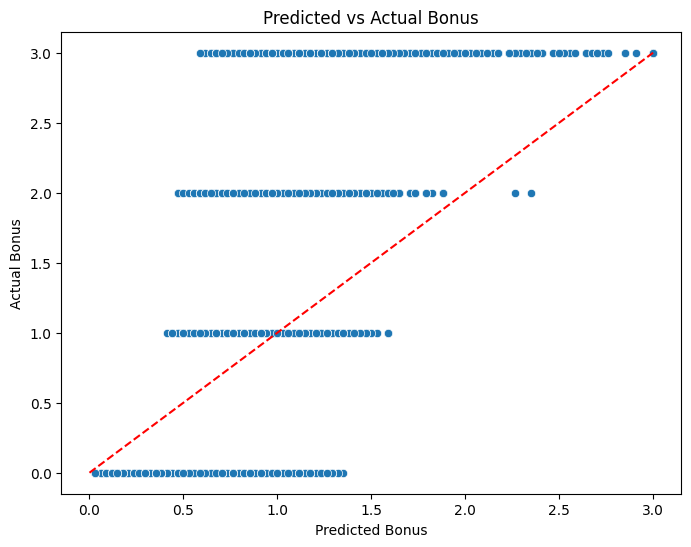

Actual Bonus       0.0       1.0       2.0       3.0
Position                                            
DEF           0.459480  0.228270  1.107821  1.945970
FWD           0.331687  0.197888  1.047859  1.711590
GK            0.488773  0.244837  1.112871  2.009231
GKP                NaN       NaN       NaN       NaN
MID           0.396976  0.244545  1.050105  1.827050


C:\Users\Chris\AppData\Local\Temp\ipykernel_18360\3541705010.py:34: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rmse_table = dfb.groupby(['position', 'bonus']).apply(lambda x: rmse(x['bonus'], x['bonus_pred']))


In [29]:
# Generalize the relationship between bps & bonus points
import statsmodels.formula.api as smf
dfb=df.copy()
filtered = (dfb['minutes']>45) & (dfb['bonus']>=0) & (dfb['bps']>0) & (dfb['position'].isin(['GK','DEF','MID','FWD']))
# df['bonus_sq'] = df['bonus']**2

model = smf.ols('bonus ~ bps -1', data=dfb[filtered]).fit()
print(model.summary())

dfb['bonus_pred'] = model.predict(dfb[filtered])
dfb['bonus_pred'] = np.clip(dfb['bonus_pred'], 0, 3) # clip prediction to 3

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(x='bonus_pred', y='bonus', data=dfb)
plt.plot([dfb['bonus'].min(), dfb['bonus'].max()],
         [dfb['bonus'].min(), dfb['bonus'].max()],
         color='red', linestyle='--')  # 45-degree line
plt.xlabel('Predicted Bonus')
plt.ylabel('Actual Bonus')
plt.title('Predicted vs Actual Bonus')
plt.show()

import pandas as pd
import numpy as np

# Function to calculate RMSE
def rmse(actual, predicted):
    return np.sqrt(np.mean((actual - predicted) ** 2))

# Group by position and actual bonus, then calculate RMSE
rmse_table = dfb.groupby(['position', 'bonus']).apply(lambda x: rmse(x['bonus'], x['bonus_pred']))

# Convert to DataFrame
rmse_table = rmse_table.reset_index()
rmse_table.columns = ['Position', 'Actual Bonus', 'RMSE']

pivot_rmse = rmse_table.pivot(index='Position', columns='Actual Bonus', values='RMSE')
print(pivot_rmse)


In [30]:
#Add bonus prediction to data
prediction_data['bonus_pred'] = model.predict(prediction_data)
print("bonus_pred added to prediction data")

bonus_pred added to prediction data


C:\Users\Chris\AppData\Local\Temp\ipykernel_18360\2545047019.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['bonus_pred'] = model.predict(prediction_data)


In [31]:
target_col_name = 'xsavesp90_pred'
saves_model_dict = {'GK':GK_saves_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, saves_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_18360\803536942.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, saves_model_dict, col_name=target_col_name)


count    210.000000
mean       3.138857
std        0.574802
min        1.097010
25%        2.790511
50%        3.070300
75%        3.430823
max        4.794433
Name: xsavesp90_pred, dtype: float64

In [32]:
target_col_name = 'xdefconp90_pred'
defcon_model_dict = {'FWD': FWD_defcon_predictor, 'MID': MID_defcon_predictor, 'DEF': DEF_defcon_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, defcon_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_18360\2777375241.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, defcon_model_dict, col_name=target_col_name)


count    2916.000000
mean        8.142230
std         1.819578
min         3.267850
25%         6.953386
50%         8.213932
75%         9.518753
max        16.270990
Name: xdefconp90_pred, dtype: float64

In [33]:
prediction_data[prediction_data['position']=='MID'].head()[["player_name_id","element","value","team_name","position","season","event","opp_team_name","opp_team_elo"
    ,'mins_pred','xgp90_pred','xap90_pred','xgcp90_pred'
    ]]

,player_name_id,element,value,team_name,position,season,event,opp_team_name,opp_team_elo,mins_pred,xgp90_pred,xap90_pred,xgcp90_pred
135611,Adam Wharton,273.0,50.0,Crystal Palace,MID,20252026.0,33.0,West Ham,996.205478,61.537185,0.056907,0.100386,1.194357
135613,Adam Wharton,273.0,50.0,Crystal Palace,MID,20252026.0,34.0,Liverpool,1158.609756,61.484835,0.056024,0.075011,1.548264
135615,Adam Wharton,273.0,50.0,Crystal Palace,MID,20252026.0,35.0,Bournemouth,1083.144286,61.894672,0.056768,0.093443,1.432038
135617,Adam Wharton,273.0,50.0,Crystal Palace,MID,20252026.0,36.0,Everton,1075.115184,61.522945,0.056768,0.105115,1.453654
135619,Adam Wharton,273.0,50.0,Crystal Palace,MID,20252026.0,37.0,Brentford,1073.538381,60.928400,0.056768,0.095436,1.487419


In [34]:
prediction_data[
    (prediction_data['event']==current_gw+1)
    &(prediction_data['mins_pred']>0)
    ][["player_name_id","element","value","team_name","position","season","event","opp_team_name","opp_team_elo"
    ,'mins_pred','xgp90_pred','xap90_pred','xgcp90_pred'
    ]].sort_values(by='xgp90_pred',ascending=False
        ).head(10)

,player_name_id,element,value,team_name,position,season,event,opp_team_name,opp_team_elo,mins_pred,xgp90_pred,xap90_pred,xgcp90_pred
138661,Chris Wood,525.0,71.0,Nott'm Forest,FWD,20252026.0,33.0,Burnley,880.681360,40.057429,0.789675,0.387846,1.466258
146609,Lorenzo Lucca,805.0,55.0,Nott'm Forest,FWD,20252026.0,33.0,Burnley,880.681360,44.581514,0.776211,0.261721,1.367647
138360,Charalampos Kostoulas,181.0,48.0,Brighton,FWD,20252026.0,33.0,Spurs,958.476619,34.665397,0.677924,0.267931,1.361171
145689,Justin Kluivert,81.0,69.0,Bournemouth,MID,20252026.0,33.0,Leeds,984.361246,48.552959,0.671843,0.340216,2.669190
145687,Justin Kluivert,81.0,69.0,Bournemouth,MID,20252026.0,33.0,Newcastle,1078.258565,49.179246,0.657588,0.320565,2.047855
147762,Marc Guiu Paz,252.0,40.0,Chelsea,FWD,20252026.0,33.0,Man Utd,1111.954027,39.037450,0.651757,0.336835,1.558260
147763,Marc Guiu Paz,252.0,40.0,Chelsea,FWD,20252026.0,33.0,Brighton,1097.373304,39.787450,0.645871,0.337000,1.537862
144780,Jonah Kusi-Asare,737.0,45.0,Fulham,FWD,20252026.0,33.0,Brentford,1073.538381,32.312125,0.645371,0.287068,1.799679
153174,Stefanos Tzimas,180.0,52.0,Brighton,FWD,20252026.0,33.0,Spurs,958.476619,39.751493,0.627841,0.410407,1.428277
141408,Fábio Freitas Gouveia Carvalho,123.0,46.0,Brentford,MID,20252026.0,33.0,Fulham,1041.541026,38.911505,0.627624,0.372979,2.666267


In [35]:
import pandas as pd
from scipy.stats import nbinom

def calculate_negbinom_parameters(position_list, df):

    # 1. Calculate mean and variance
    filtered = (df['minutes'] > 0) & (df['defensive_contribution_per90'] > 0) & (df['defensive_contribution_per90'] < 40) & (df['position'].isin(position_list))
    mean = df[filtered]['defensive_contribution_per90'].mean()
    variance = df[filtered]['defensive_contribution_per90'].var()
    # r = number of successes
    r = (mean**2) / (variance - mean)
    # p = success probability
    p = r / (r + mean)
    return r,p

In [36]:
from scipy.stats import poisson
import numpy as np

def expected_score(mu, max_events=10, rule=None, points_per_n=None, points_value=None):
    """
    Calculate the expected score given an average event rate (mu)
    using a Poisson model.

    Parameters
    ----------
    mu : float
        Expected number of events (e.g., goals conceded, shots saved).
    max_events : int
        Maximum number of discrete events to sum over.
    rule : callable, optional
        Function that maps event count -> points. Example: lambda k: -np.floor(k / 2)
    points_per_n : int, optional
        For simple rules: number of events required for one point (e.g. 3 shots saved = 1 pt)
    points_value : float, optional
        Value of that one point (e.g. +1 for shots saved, -1 for goals conceded)

    Returns
    -------
    float
        Expected points based on Poisson-distributed event counts.
    """
    array = np.arange(0, max_events + 1)
    probs = poisson.pmf(array, mu)

    if rule is not None:
        scores = np.array([rule(k) for k in array])
    elif points_per_n is not None and points_value is not None:
        # General simple rule: 1 point_value for every n events
        scores = np.floor(array / points_per_n) * points_value
    else:
        raise ValueError("You must provide either a rule function or both points_per_n and points_value.")

    return np.sum(scores * probs)


In [37]:
from scipy.stats import norm
import numpy as np

scoring_dict = {
    "FWD": {'xgp90_pred': 4, 'xap90_pred': 3, 'xgcp90_pred': 0, 'xgc_ss':0, 'defcon':2},
    "MID": {'xgp90_pred': 5, 'xap90_pred': 3, 'xgcp90_pred': 1, 'xgc_ss':0, 'defcon':2},
    "DEF": {'xgp90_pred': 6, 'xap90_pred': 3, 'xgcp90_pred': 4, 'xgc_ss':-1, 'defcon':2},
    "GK":  {'xgp90_pred': 10, 'xap90_pred': 3, 'xgcp90_pred': 4, 'xgc_ss':-1, 'defcon':2}
}

def scoring(x, scoring_dict, points_type, negbinom_rp_dict=None):
    mins_factor = x['mins_pred']/90
    if points_type == 'mins':
        if pd.isna(x['mins_pred']):
            return 0
        elif x['mins_pred'] > 0:
            return 1 + 1 / (1 + np.exp(-(x['mins_pred'] - 60) / 10)) #smooth logistic approximation from 1 to 2 points, 10 is a scale factor
        
    if points_type == 'goals':
        goals_points = mins_factor * x['xgp90_pred'] * scoring_dict[x['position']]['xgp90_pred']
        return goals_points
    if points_type == 'assists':
        assist_points = mins_factor * x['xap90_pred'] * scoring_dict[x['position']]['xap90_pred']
        return assist_points
    if points_type == 'clean_sheets':
        p_less_than_1 = poisson.cdf(0, mu=x['xgcp90_pred'])
        cs_points = p_less_than_1 * scoring_dict[x['position']]['xgcp90_pred']
        return cs_points
    
    if points_type == 'shots_saved': 
        if x['position'] == 'GK':
            saves_points = expected_score(mu=x['xsavesp90_pred'],  # expected shots saved per 90
                                   max_events=15,
                                   points_per_n=3, #for every 3 shots saved
                                   points_value=1) #scores 1 point
            return saves_points
        else:
            return 0
        
    if points_type == 'goals_conceded':
        if x['position'] in ['DEF','GK']:
            gc_points = expected_score(mu=x['xgcp90_pred'], 
                                   max_events=10, 
                                   points_per_n=2, #for every 2 goals conceded 
                                   points_value=-1) #scores -1 points 
            return gc_points
        else:
            return 0

    if points_type == 'defcon':
        pos = x['position']
        if pos in ['MID','FWD']:
            r = negbinom_rp_dict[pos]['r']
            p = negbinom_rp_dict[pos]['p']
            k = 12
            prob_more_than_12 = 1 - nbinom.cdf(k, r, p)
            defcon_points = prob_more_than_12 * scoring_dict[pos]['defcon']
            return defcon_points
        elif pos == 'DEF':
            r = negbinom_rp_dict[pos]['r']
            p = negbinom_rp_dict[pos]['p']
            k = 10
            prob_more_than_12 = 1 - nbinom.cdf(k, r, p)
            defcon_points = prob_more_than_12 * scoring_dict[pos]['defcon']
            return defcon_points
        else: return 0

    if points_type == 'bonus':
        return x['xbpsp90_pred']*0.0294 # ols regression coefficient

prediction_data['xpoints_mins'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='mins'), axis=1)
prediction_data['xpoints_goals'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='goals'), axis=1)
prediction_data['xpoints_assists'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='assists'), axis=1)
prediction_data['xpoints_clean_sheets'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='clean_sheets'), axis=1)

prediction_data['xpoints_shots_saved'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='shots_saved'), axis=1)
prediction_data['xpoints_goals_conceded'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='goals_conceded'), axis=1)

def_r,def_p = calculate_negbinom_parameters(['DEF'], df)
mid_r,mid_p = calculate_negbinom_parameters(['MID'], df)
fwd_r,fwd_p = calculate_negbinom_parameters(['FWD'], df)
rp_dict = {'DEF':{'r':def_r,'p':def_p},'MID':{'r':mid_r,'p':mid_p},'FWD':{'r':fwd_r,'p':fwd_p}}
prediction_data['xpoints_defcon'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='defcon', negbinom_rp_dict=rp_dict), axis=1)
prediction_data['xpoints_bonus'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='bonus'), axis=1)

prediction_data['xpoints'] = prediction_data[['xpoints_mins', 'xpoints_goals', 'xpoints_assists', 'xpoints_clean_sheets',
                                              'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus']].sum(axis=1, skipna=True)

C:\Users\Chris\AppData\Local\Temp\ipykernel_18360\3158721815.py:71: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['xpoints_mins'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='mins'), axis=1)
C:\Users\Chris\AppData\Local\Temp\ipykernel_18360\3158721815.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['xpoints_goals'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='goals'), axis=1)
C:\Users\Chris\AppData\Local\Temp\ipykerne

In [38]:
predictions = prediction_data[['player_name_id', 'team_name','team_elo','element','position','opp_team_name','opp_team_elo', 'season', 'value', 'event','fixture',
                       'mins_pred', 'xgp90_pred', 'xap90_pred', 'xgcp90_pred',
                       'xpoints_mins', 'xpoints_goals', 'xpoints_assists', 'xpoints_clean_sheets','xpoints_shots_saved',
                       'xpoints_goals_conceded','xpoints_defcon','xpoints_bonus','xpoints']]
fixture_predictions = predictions.copy()  # keep per-fixture detail
# Existing per-fixture xpoints are computed above
# Now aggregate to gameweek level by summing across fixtures within each event

predictions_by_gw = predictions.groupby(
    ['player_name_id', 'element', 'team_name', 'position', 'season', 'event', 'value'],
    as_index=False,
    dropna=False
).agg(
    # descriptive
    team_name=('team_name', 'first'),
    team_elo=('team_elo', 'first'),
    opp_team_name=('opp_team_name', lambda x: '; '.join(x.dropna())), # concatenate opponent names for multiple fixtures
    opp_team_elo=('opp_team_elo', 'mean'),
    position=('position', 'first'),
    value=('value', 'first'),
    #count fixtures to identify DGWs
    fixture_count=('fixture', 'count'),
    #sum points components across fixtures
    mins_pred=('mins_pred', 'sum'),
    xpoints=('xpoints', 'sum'),
    xpoints_mins=('xpoints_mins', 'sum'),
    xpoints_goals=('xpoints_goals', 'sum'),
    xpoints_assists=('xpoints_assists', 'sum'),
    xpoints_clean_sheets=('xpoints_clean_sheets', 'sum'),
    xpoints_shots_saved=('xpoints_shots_saved', 'sum'),
    xpoints_goals_conceded=('xpoints_goals_conceded', 'sum'),
    xpoints_defcon=('xpoints_defcon', 'sum'),
    xpoints_bonus=('xpoints_bonus', 'sum'),
    # rates average across fixtures
    xgp90_pred=('xgp90_pred', 'mean'),
    xap90_pred=('xap90_pred', 'mean'),
    xgcp90_pred=('xgcp90_pred', 'mean'),
)

predictions_by_gw[predictions_by_gw['player_name_id'].isna()]

,player_name_id,element,season,event,team_name,team_elo,opp_team_name,opp_team_elo,position,value,...,xpoints_goals,xpoints_assists,xpoints_clean_sheets,xpoints_shots_saved,xpoints_goals_conceded,xpoints_defcon,xpoints_bonus,xgp90_pred,xap90_pred,xgcp90_pred


In [39]:
#use for fixture-level analysis
table_name = "predictions_by_fixture"
if __name__ == "__main__":
    db_creator.create_staging_table_then_insert_data(table_name, data=fixture_predictions)
    # preds = db_creator.table_to_df(table_name=table_name)
    # print(preds.info())

In [40]:
#use to make transfer decisions at gameweek level
table_name = "predictions"
if __name__ == "__main__":
    db_creator.create_staging_table_then_insert_data(table_name, data=predictions_by_gw)
    preds = db_creator.table_to_df(table_name=table_name)
    print(preds.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2972 entries, 0 to 2971
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   player_name_id          2972 non-null   object 
 1   element                 2972 non-null   float64
 2   season                  2972 non-null   float64
 3   event                   2972 non-null   float64
 4   team_name               2972 non-null   object 
 5   team_elo                2972 non-null   float64
 6   opp_team_name           2972 non-null   object 
 7   opp_team_elo            2972 non-null   float64
 8   position                2972 non-null   object 
 9   value                   2972 non-null   float64
 10  fixture_count           2972 non-null   float64
 11  mins_pred               2972 non-null   float64
 12  xpoints                 2972 non-null   float64
 13  xpoints_mins            2972 non-null   float64
 14  xpoints_goals           2972 non-null   

In [41]:
# Add new columns to the xPoints table
db_creator.execute_sql("""
    ALTER TABLE predictions
    ADD COLUMN IF NOT EXISTS in_any_team INTEGER DEFAULT 0,
    ADD COLUMN IF NOT EXISTS in_my_team INTEGER DEFAULT 0
""")

In [42]:
my_name = "Christopher Harris"

# Get the player lists
view = db_creator.run_sql(f"""
    WITH 
    current_players AS (
        SELECT element
        FROM fpl_picks
        WHERE gw = {current_gw}
    ),
    my_players AS (
        SELECT element
        FROM fpl_picks
        WHERE gw = {current_gw}
        AND member = '{my_name}'
    )
    SELECT * FROM my_players
""")

# Update the flags
db_creator.execute_sql(f"""
    UPDATE predictions
    SET in_any_team = 1
    WHERE element IN (
        SELECT element 
        FROM fpl_picks 
        WHERE gw = {current_gw}
    )
""")

db_creator.execute_sql(f"""
    UPDATE predictions
    SET in_my_team = 1
    WHERE element IN (
        SELECT element 
        FROM fpl_picks 
        WHERE gw = {current_gw}
        AND member = '{my_name}'
    )
""")

In [43]:
view = db_creator.run_sql("""SELECT
                        player_name_id, team_name, team_elo, season, event, fixture_count, opp_team_name, opp_team_elo
                            FROM predictions
                        WHERE season = 20252026 
                          AND event = 33
                          AND player_name_id = 'Cole Palmer'
                            """)
view

,player_name_id,team_name,team_elo,season,event,fixture_count,opp_team_name,opp_team_elo
0,Cole Palmer,Chelsea,1112.865267,20252026.0,33.0,2.0,Man Utd; Brighton,1104.663666


In [44]:
print(f"Gameweek {current_gw+1} Predictions")
predictions_by_gw[
    predictions_by_gw['event']==current_gw+1
].pivot_table(index=['player_name_id',"element",'event',"value","team_name","position"], values='xpoints', aggfunc='sum').reset_index().sort_values(by='xpoints', ascending=False).head(20)

Gameweek 33 Predictions


,player_name_id,element,event,value,team_name,position,xpoints
263,Joško Gvardiol,403.0,33.0,59.0,Man City,DEF,9.894527
269,Justin Kluivert,81.0,33.0,69.0,Bournemouth,MID,9.804638
321,Marc Guéhi,260.0,33.0,51.0,Man City,DEF,9.634827
344,Max Alleyne,794.0,33.0,39.0,Man City,DEF,9.596998
137,Erling Haaland,430.0,33.0,144.0,Man City,FWD,9.546220
338,Mats Wieffer,173.0,33.0,49.0,Brighton,MID,9.345472
334,Matheus Nunes,407.0,33.0,53.0,Man City,DEF,9.281474
205,Jaidon Anthony,200.0,33.0,50.0,Burnley,MID,9.177358
12,Alex Scott,90.0,33.0,50.0,Bournemouth,MID,9.163529
518,Zian Flemming,215.0,33.0,53.0,Burnley,FWD,9.109203


In [45]:
print(f"Next 5 GWs: GW{current_gw+1} - GW{current_gw+5}")
next_5_gws_filter = (predictions_by_gw['event']>=current_gw)&(predictions_by_gw['event']<=current_gw+5)
predictions_by_gw[next_5_gws_filter].groupby('player_name_id')[['mins_pred', 'xpoints_mins', 'xpoints_goals', 
                                           'xpoints_assists', 'xpoints_clean_sheets', 'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus',
                                           'xpoints'
                                           ]].agg('sum').reset_index().sort_values(by='xpoints',ascending=False).head(10)

Next 5 GWs: GW33 - GW37


,player_name_id,mins_pred,xpoints_mins,xpoints_goals,xpoints_assists,xpoints_clean_sheets,xpoints_shots_saved,xpoints_goals_conceded,xpoints_defcon,xpoints_bonus,xpoints
161,Gabriel dos Santos Magalhães,422.708490,9.603858,2.178352,1.736143,8.015673,0.0,-1.343122,2.713161,2.979518,25.883582
67,Bukayo Saka,408.916811,9.491352,5.034841,2.819813,2.100718,0.0,0.000000,2.558102,2.861524,24.866350
505,William Saliba,429.703023,9.651922,1.438479,0.687327,8.730102,0.0,-1.193077,2.713161,2.754838,24.782751
64,Bruno Borges Fernandes,421.943003,9.598530,4.790356,3.203259,1.215614,0.0,0.000000,2.558102,3.389039,24.754900
269,Justin Kluivert,243.426081,6.219670,8.925206,2.626137,0.525746,0.0,0.000000,2.558102,3.709148,24.564010
267,Jurriën Timber,343.357694,8.520529,1.298991,0.888981,9.122709,0.0,-1.093047,2.713161,2.775391,24.226714
107,Declan Rice,426.072442,9.628159,3.830351,2.730798,2.182655,0.0,0.000000,2.558102,2.985719,23.915785
193,Iliman Ndiaye,425.854727,9.626376,5.323666,2.231534,1.343314,0.0,0.000000,2.558102,2.783117,23.866109
338,Mats Wieffer,420.195534,9.585612,4.160621,3.227379,1.416432,0.0,0.000000,2.558102,2.744180,23.692327
91,Crysencio Summerville,356.914296,8.777386,6.665982,1.961922,1.129390,0.0,0.000000,2.558102,2.583122,23.675904


In [46]:
print("Rest of Season Predictions")
predictions_by_gw.groupby('player_name_id')[['mins_pred', 'xpoints_mins', 'xpoints_goals', 
                                           'xpoints_assists', 'xpoints_clean_sheets', 
                                           'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus',
                                           'xpoints'
                                           ]].agg('sum').reset_index().sort_values(by='xpoints',ascending=False).head(10)

Rest of Season Predictions


,player_name_id,mins_pred,xpoints_mins,xpoints_goals,xpoints_assists,xpoints_clean_sheets,xpoints_shots_saved,xpoints_goals_conceded,xpoints_defcon,xpoints_bonus,xpoints
161,Gabriel dos Santos Magalhães,506.809688,11.521454,2.601073,2.155375,9.569806,0.0,-1.603550,3.255793,3.551209,31.051160
67,Bukayo Saka,490.873840,11.391215,6.194751,3.406573,2.518939,0.0,0.000000,3.069723,3.423303,30.004504
64,Bruno Borges Fernandes,505.818161,11.514400,5.777639,3.831036,1.426574,0.0,0.000000,3.069723,4.039359,29.658730
505,William Saliba,515.219300,11.579605,1.727158,0.819307,10.361129,0.0,-1.433186,3.255793,3.290068,29.599874
269,Justin Kluivert,291.479039,7.452088,10.749051,3.215912,0.593431,0.0,0.000000,3.069723,4.424148,29.504353
193,Iliman Ndiaye,510.179024,11.545643,6.613611,2.799437,1.651074,0.0,0.000000,3.069723,3.378585,29.058073
107,Declan Rice,510.434961,11.547709,4.794672,3.302426,2.632675,0.0,0.000000,3.069723,3.580444,28.927650
267,Jurriën Timber,411.590461,10.215461,1.570584,1.057438,10.822774,0.0,-1.316021,3.255793,3.295296,28.901325
91,Crysencio Summerville,426.143170,10.493016,8.044249,2.376783,1.417110,0.0,0.000000,3.069723,3.072088,28.472969
338,Mats Wieffer,504.279786,11.503080,5.067808,3.870242,1.632227,0.0,0.000000,3.069723,3.241381,28.384461


In [47]:
from datetime import datetime

# Add the columns
db_creator.execute_sql("""
    ALTER TABLE predictions
    ADD COLUMN IF NOT EXISTS prediction_timestamp TIMESTAMP,
    ADD COLUMN IF NOT EXISTS prediction_gameweek INTEGER;
""")

# Update ALL existing rows with current timestamp and gameweek
db_creator.execute_sql("""
    UPDATE predictions
    SET prediction_timestamp = :timestamp,
        prediction_gameweek = :gameweek;
""", params={
    'timestamp': datetime.now(),
    'gameweek': current_gw
})

In [48]:
# ## Reset predictions table

# db_creator.execute_sql("""
#     DROP TABLE IF EXISTS predictions_allgws
# """)

In [49]:
# Create predictions_allgws if it doesn't exist
db_creator.execute_sql("""
    CREATE TABLE IF NOT EXISTS predictions_allgws AS
    SELECT p.*,
            -- pg.player_name_id, pg.team_name, pg.team_elo, pg.element, pg.position, pg.opp_team_name, pg.opp_team_elo, pg.value -- these are in both tables
            SUM(pg.total_points) AS total_points
            
    FROM predictions p
    LEFT JOIN playergw pg 
        ON p.player_name_id = pg.player_name_id 
        AND p.event = pg.event
        AND p.season = pg.season
    GROUP BY p.player_name_id, p.element, p.season, p.event,
             p.team_name, p.team_elo, p.position, p.value, p.in_any_team, p.in_my_team,
             p.opp_team_name, p.opp_team_elo, p.fixture_count,
             p.xpoints, p.xpoints_mins, p.xpoints_goals, p.xpoints_assists,
             p.xpoints_clean_sheets, p.xpoints_shots_saved, p.xpoints_goals_conceded,
             p.xpoints_defcon, p.xpoints_bonus,
             p.mins_pred, p.xgp90_pred, p.xap90_pred, p.xgcp90_pred,
             p.prediction_timestamp, p.prediction_gameweek
    Limit 0 -- no data yet, just create the table structure;
""")

In [50]:
# Step 1: Insert new predictions with current timestamp
# This will create NEW rows even for gameweeks that already have predictions
db_creator.execute_sql("""
INSERT INTO predictions_allgws (
    player_name_id, team_name, team_elo, element, position, opp_team_name, opp_team_elo, value, 
    event, season, xpoints, 
    prediction_timestamp, prediction_gameweek,
    fixture, total_points
)
SELECT 
    p.player_name_id, p.team_name, p.team_elo, p.element, p.position, p.opp_team_name, 
    p.opp_team_elo, p.value, p.event, p.season, p.xpoints, 
    p.prediction_timestamp, p.prediction_gameweek,
    pg.fixture, pg.total_points
FROM predictions p
LEFT JOIN playergw pg 
    ON p.player_name_id = pg.player_name_id 
    AND p.event = pg.event 
    AND p.season = pg.season;
""")

print(f"Successfully added {db_creator.run_sql('SELECT COUNT(*) FROM predictions').iloc[0,0]} new predictions to predictions_allgws")

Successfully added 2972 new predictions to predictions_allgws


In [51]:
view = db_creator.table_to_df('predictions_allgws')
future_filter = (
    view['prediction_gameweek']==current_gw) & (
    view['event']==current_gw+1) & (
    view['player_name_id']=='Erling Haaland')
view[['player_name_id','season','event','fixture','total_points']][future_filter].head()

,player_name_id,season,event,fixture,total_points
122325,Erling Haaland,20252026.0,33.0,NaN,NaN
122326,Erling Haaland,20252026.0,33.0,NaN,NaN
122327,Erling Haaland,20252026.0,33.0,NaN,NaN
122328,Erling Haaland,20252026.0,33.0,NaN,NaN
125599,Erling Haaland,20252026.0,33.0,327.0,NaN


In [52]:
view = db_creator.table_to_df('playergw')
future_filter = (view['season']==20252026)&(view['event']>=25)&(view['player_name_id']=='Erling Haaland')
view[['player_name_id','event','season','total_points','minutes']][future_filter].sort_values(by='event').head(10)

,player_name_id,event,season,total_points,minutes
191664,Erling Haaland,25.0,20252026.0,11.0,90.0
191665,Erling Haaland,26.0,20252026.0,5.0,45.0
191666,Erling Haaland,27.0,20252026.0,6.0,90.0
191667,Erling Haaland,28.0,20252026.0,0.0,0.0
191668,Erling Haaland,29.0,20252026.0,2.0,90.0
191669,Erling Haaland,30.0,20252026.0,2.0,90.0
191670,Erling Haaland,32.0,20252026.0,0.0,0.0
205412,Erling Haaland,33.0,20252026.0,NaN,NaN
205416,Erling Haaland,33.0,20252026.0,NaN,NaN
205417,Erling Haaland,35.0,20252026.0,NaN,NaN


In [53]:
view = db_creator.table_to_df('predictions_allgws')
view[['player_name_id','prediction_timestamp','event','xpoints','total_points']][
    (view['season']==20252026)&(
    view['event']>=20)&(view['player_name_id']=='Erling Haaland')].sort_values(by='event')

,player_name_id,prediction_timestamp,event,xpoints,total_points
1615,Erling Haaland,2026-01-05 18:33:33.065519,21.0,5.628327,6.0
13463,Erling Haaland,2026-01-05 18:33:33.065519,22.0,5.571476,2.0
13479,Erling Haaland,2026-01-05 18:33:33.065519,23.0,7.368988,1.0
13464,Erling Haaland,2026-01-05 18:33:33.065519,24.0,5.915376,NaN
5663,Erling Haaland,2026-01-26 14:27:00.627006,24.0,4.148815,NaN
...,...,...,...,...,...
112461,Erling Haaland,2026-04-07 15:05:46.048624,38.0,4.221372,NaN
119451,Erling Haaland,2026-04-09 16:15:18.991612,38.0,4.204206,NaN
122871,Erling Haaland,2026-04-11 19:52:12.859110,38.0,4.091495,NaN
125601,Erling Haaland,2026-04-12 12:24:18.382275,38.0,4.267749,NaN


In [54]:
# Get the data from the predictions table
df_preds = db_creator.table_to_df('predictions_allgws')

# Remove rows where actual_points is missing
gw_filter=(df_preds['prediction_gameweek']>=13)&(
            df_preds['event']>=current_gw)&(
                df_preds['event']<=current_gw+5)&(
            df_preds['season']==20252026)#&(
            #df_preds['player_name_id']=='Erling Haaland')
df_complete = df_preds[gw_filter]

df_complete.pivot_table(index=['prediction_timestamp','prediction_gameweek','season','event'], values=['xpoints','total_points'])

xpoints
prediction_timestamp       prediction_gameweek season     event          
2026-01-05 18:33:33.065519 20                  20252026.0 32.0   3.417936
                                                          33.0   3.403198
                                                          34.0   3.418776
                                                          35.0   3.388855
                                                          36.0   3.436291
...                                                                   ...
2026-04-12 13:59:27.354799 32                  20252026.0 33.0   4.954609
                                                          34.0   3.410362
                                                          35.0   3.414797
                                                          36.0   3.349391
                                                          37.0   3.361312

[171 rows x 1 columns]

In [55]:
#Future GWs should show more than one row here when more predictions are added...
df_complete.pivot_table(index='prediction_timestamp',values='player_name_id',aggfunc='count',dropna=False)

,player_name_id
prediction_timestamp,
2026-01-05 18:33:33.065519,2910
2026-01-07 16:29:20.849190,12
2026-01-08 16:44:49.940956,12
2026-01-22 16:59:38.976316,18
2026-01-25 11:24:25.347489,6
2026-01-26 14:27:00.627006,2970
2026-01-27 11:00:04.422834,2976
2026-02-01 11:57:12.353330,2988
2026-02-02 13:38:00.840050,3006


In [56]:
df_complete.columns.to_list()

['player_name_id',
 'team_name',
 'team_elo',
 'element',
 'position',
 'opp_team_name',
 'opp_team_elo',
 'season',
 'value',
 'event',
 'mins_pred',
 'xgp90_pred',
 'xap90_pred',
 'xgcp90_pred',
 'xpoints_mins',
 'xpoints_goals',
 'xpoints_assists',
 'xpoints_clean_sheets',
 'xpoints_shots_saved',
 'xpoints_goals_conceded',
 'xpoints_defcon',
 'xpoints_bonus',
 'xpoints',
 'in_any_team',
 'in_my_team',
 'prediction_timestamp',
 'prediction_gameweek',
 'total_points',
 'fixture']

In [57]:
filtered = (df_complete['player_name_id'] == 'Erling Haaland')&(
    df_complete['season']==20252026) & (df_complete['event']==current_gw+1)
df_complete[filtered][['prediction_timestamp','prediction_gameweek','season','event','xpoints','total_points']].sort_values(by='prediction_timestamp')

,prediction_timestamp,prediction_gameweek,season,event,xpoints,total_points
13473,2026-01-05 18:33:33.065519,20,20252026.0,33.0,4.478146,NaN
5668,2026-01-26 14:27:00.627006,23,20252026.0,33.0,3.542623,NaN
19370,2026-01-27 11:00:04.422834,23,20252026.0,33.0,3.475960,NaN
26616,2026-02-01 11:57:12.353330,24,20252026.0,33.0,3.204079,NaN
33633,2026-02-02 13:38:00.840050,24,20252026.0,33.0,3.755389,NaN
40650,2026-02-03 14:41:19.430154,24,20252026.0,33.0,4.027643,NaN
47464,2026-02-09 12:29:03.939012,25,20252026.0,33.0,4.547072,NaN
53798,2026-02-13 13:00:38.658664,26,20252026.0,33.0,4.492147,NaN
59828,2026-02-19 17:56:20.307174,26,20252026.0,33.0,4.373983,NaN
65859,2026-02-20 10:52:25.776847,26,20252026.0,33.0,4.386840,NaN


In [58]:
filtered = df_complete['prediction_gameweek']==21
df_complete[filtered][['prediction_timestamp','player_name_id','event']].describe()

,prediction_timestamp,event
count,24,24.000000
mean,2026-01-08 04:37:05.395073024,34.500000
min,2026-01-07 16:29:20.849190,32.000000
25%,2026-01-07 16:29:20.849189888,33.000000
50%,2026-01-08 04:37:05.395073024,34.500000
75%,2026-01-08 16:44:49.940955904,36.000000
max,2026-01-08 16:44:49.940956,37.000000
std,NaN,1.744557


In [59]:
# # Create the plot
# plt.figure(figsize=(10, 8))
# sns.scatterplot(data=df_complete, x='xpoints', y='total_points', alpha=0.6)

# # Add a diagonal reference line (perfect predictions)
# max_val = max(df_complete['xpoints'].max(), df_complete['total_points'].max())
# plt.plot([0, max_val], [0, max_val], 'r--', label='Perfect prediction', linewidth=2)

# # Add regression line showing actual correlation
# from scipy.stats import linregress
# slope, intercept, r_value, p_value, std_err = linregress(df_complete['xpoints'], df_complete['total_points'])
# x_line = np.array([df_complete['xpoints'].min(), df_complete['xpoints'].max()])
# y_line = slope * x_line + intercept
# plt.plot(x_line, y_line, 'g-', label=f'Best fit (y={slope:.2f}x+{intercept:.2f})', linewidth=2)

# print(f"Correlation: {df_complete['xpoints'].corr(df_complete['total_points']):.3f}")
# print(f"Mean Absolute Error: {(df_complete['xpoints'] - df_complete['total_points']).abs().mean():.3f}")
# print(f"Root Mean Squared Error: {((df_complete['xpoints'] - df_complete['total_points'])**2).mean()**0.5:.3f}")

# plt.xlabel('Predicted Points (xPoints)', fontsize=12)
# plt.ylabel('Actual Points', fontsize=12)
# plt.title(f'Predicted vs Actual Points in GW{current_gw}', fontsize=14, fontweight='bold')
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()

In [60]:
finish=time.perf_counter()
print(f'Finished in {round(((finish-start)/60),2)} minute(s)')
#10/11/25: Finished in 33.17 minute(s)

Finished in 34.45 minute(s)


In [61]:
# Notification when file has finished running
from plyer import notification

notification.notify(
    title='Script Complete',
    message='Your file has finished running!',
    app_name='Jupyter Notebook',
    timeout=20  # notification stays for 20 seconds
)